# A minimal FCNN with sigmoid

We build a vanilla FCNN with sigmoid and then look at the main issue with sigmoid in deeper Fully Connected Neural Networks: vanishing gradients.


## Setup things

Make sure your environment has all the required packages available. Take care to have

- keras
- a backend of your choosing for Keras (we will stay with Tensorflow for now)
- scikit-learn

We use MNIST from Keras and keep only the digits 4 and 9, giving us a small binary classification task with no external data files.


In [14]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import numpy as np
from sklearn.model_selection import train_test_split
from utils import eval_model_classification, train_model, eval_model

print(f"Using Keras {keras.__version__} with backend: {keras.backend.backend()}")

Using Keras 3.12.0 with backend: tensorflow


### Check for GPU


In [2]:
import keras
import tensorflow as tf

print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices("GPU"))

Built with CUDA: False
GPU devices: []


## Loading and preparing the dataset

We will build a small "hello world" FCNN example using a binary classification task on the MNIST digits recognition dataset, filtered to fours and nines.
Q: These are actually images, can we input those into a FCNN directly? Shape?


In [3]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = (
    keras.datasets.mnist.load_data()
)

# Let's try to differentiate 4s and 9s in the MNIST dataset first.
train_mask = np.isin(y_train_full, [4, 9])
test_mask = np.isin(y_test_full, [4, 9])

X_train_full = X_train_full[train_mask]
y_train_full = (y_train_full[train_mask] == 9).astype("float32")
X_test = X_test_full[test_mask]
y_test = (y_test_full[test_mask] == 9).astype("float32")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)
# reshape is necessary, bcause a fcnn takes what as input?
X_train_scaled = X_train.reshape(len(X_train), -1).astype("float32") / 255.0
X_val_scaled = X_val.reshape(len(X_val), -1).astype("float32") / 255.0
X_test_scaled = X_test.reshape(len(X_test), -1).astype("float32") / 255.0

print("Train:", X_train_scaled.shape, y_train.shape)
print("Validation:", X_val_scaled.shape, y_val.shape)
print("Test:", X_test_scaled.shape, y_test.shape)

Train: (9432, 784) (9432,)
Validation: (2359, 784) (2359,)
Test: (1991, 784) (1991,)


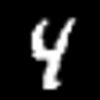

In [4]:
from PIL import Image
import numpy as np

img = X_train_scaled[1].reshape(28, 28)
img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
Image.fromarray(img_u8, mode="L").resize((100, 100))

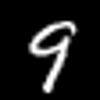

In [5]:
img = X_train_scaled[7000].reshape(28, 28)
img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
Image.fromarray(img_u8, mode="L").resize((100, 100))

## A vanilla FCNN

basic one-hidden-layer network: flattened input -> dense hidden layer with sigmoid activ.-> which output activation for binary?.


In [6]:
# lets take a look at the shape
X_train_scaled.shape

(9432, 784)

In [7]:
model_sigmoid = keras.models.Sequential(
    [
        keras.layers.Input(
            shape=(X_train_scaled.shape[1],),
        ),
        keras.layers.Dense(32, activation="sigmoid"),  # relu
        keras.layers.Dense(1, activation="sigmoid"),  # relu
    ]
)

model_sigmoid.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)
model_sigmoid.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,153 (98.25 KB)

 Trainable params: 25,153 (98.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# use early stopping callback to halt training if no improvment visible
## https://keras.io/api/callbacks/
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)


history_sigmoid = model_sigmoid.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

res = eval_model_classification(
    model_sigmoid,
    X_test_scaled,
    y_test,
    "One Hidden Layer Sigmoid Network",
)

Epoch 1/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9186 - loss: 0.2943 - val_accuracy: 0.9534 - val_loss: 0.1502
Epoch 2/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9640 - loss: 0.1221 - val_accuracy: 0.9627 - val_loss: 0.1099
Epoch 3/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9680 - loss: 0.0989 - val_accuracy: 0.9644 - val_loss: 0.0996
Epoch 4/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9706 - loss: 0.0888 - val_accuracy: 0.9674 - val_loss: 0.0955
Epoch 5/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9716 - loss: 0.0838 - val_accuracy: 0.9682 - val_loss: 0.0925
Epoch 6/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9738 - loss: 0.0786 - val_accuracy: 0.9691 - val_loss: 0.0885
Epoch 7/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9741 - loss: 0.0754 - val_accuracy: 0.9695 - val_loss: 0.0873
Epoch 8/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9756 - loss: 0.0717 - val_accuracy: 0.

In [ ]:
## Dropout
model_with_dropout = keras.models.Sequential(
    [
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(512, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation=None),
    ]
)

model_with_dropout.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_with_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 576,513 (2.20 MB)

 Trainable params: 576,513 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_with_dropout = train_model(
    model_with_dropout, X_train_scaled, y_train, "with_dropout", epochs=10
)
eval_model(model_with_dropout, X_test_scaled, y_test, "with_dropout")

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0083 - mae: 0.0589 - val_loss: 0.0122 - val_mae: 0.0321
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0083 - mae: 0.0597 - val_loss: 0.0111 - val_mae: 0.0249
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0077 - mae: 0.0587 - val_loss: 0.0081 - val_mae: 0.0257
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0080 - mae: 0.0594 - val_loss: 0.0090 - val_mae: 0.0216
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0070 - mae: 0.0584 - val_loss: 0.0060 - val_mae: 0.0255
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0064 - mae: 0.0574 - val_loss: 0.0068 - val_mae: 0.0213
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0062 - mae: 0.0561 - val_loss: 0.0055 - val_mae: 0.0155
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0070 - mae: 0.0578 - val_loss: 0.0109 - val_mae: 0.0322
Epoch 9/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - l

(0.008593481965363026, 0.018748948350548744, 0.9656197428703308)